# 🚨 Smart Emergency Dispatch — SFT → GRPO Training (Colab + Unsloth)

Fine-tunes **Qwen3-1.7B** as an emergency 911 dispatcher using **Unsloth** for 2× faster training:
1. **Phase 1 — SFT**: Teach the model the JSON output format
2. **Phase 2 — GRPO**: Improve dispatch strategy via RL against the live HF Space environment

**Runtime**: Google Colab with T4 or A100 GPU

## 0 · Install Dependencies

In [48]:
!pip install -Uq unsloth vllm
!pip install matplotlib
!pip install "jedi>=0.16" "opentelemetry-api<1.39.0" "opentelemetry-sdk<1.39.0"
!pip install -Uq "trl<=0.24.0"
!pip install -Uq git+https://github.com/meta-pytorch/OpenEnv.git
!pip install -Uq git+https://github.com/rishiraj38/Smart_Emergency.git "datasets<4.4.0" requests


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 139.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 107.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 201.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 68.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 192.2 MB/s eta 0:00:00
  Using cached opentelemetry_api-1.38.0-py3-none-any.whl (65 kB)
  Using cached opentelemetry_sdk-1.38.0-py3-none-any.whl (132 kB)
  Using cached opentelemetry_semantic_conventions-0.59b0-py3-none-any.whl (207 kB)
  Attempting uninstall: opentelemetry-api
    Found existing installation: opentelemetry-api 1.41.1
    Uninstalling opentelemetry-api-1.41.1:
      Successfully uninstalled opentelemetry-api-1.41.1
  Attempting uninstall: opentelemetry-semantic-conventions
    Found existing installation: opentelemetry-semantic-conventions 0.62b1
    Uninstalling opentelemetry-semantic-co

In [50]:
from huggingface_hub import notebook_login
notebook_login()

In [51]:
# Patch 1: transformers bug — crashes on repos without additional_chat_templates/
import unsloth
import transformers.utils.hub as _hub
_orig_list = _hub.list_repo_templates
def _safe_list(*a, **kw):
    try: return _orig_list(*a, **kw)
    except Exception: return []
_hub.list_repo_templates = _safe_list

# Patch 2: peft/transformers mismatch — EmbeddingParallel missing
import transformers.integrations.tensor_parallel as _tp
if not hasattr(_tp, 'EmbeddingParallel'):
    _tp.EmbeddingParallel = _tp.ColwiseParallel

print("⚠️ Applied compatibility patches")


⚠️ Applied compatibility patches


## 1 · Configuration

In [52]:
import os, json, re, random, requests, time
from collections import defaultdict

MODEL_NAME = "unsloth/Qwen3-1.7B-unsloth-bnb-4bit"
SFT_OUTPUT_DIR = "smart-emergency-sft"
GRPO_OUTPUT_DIR = "smart-emergency-grpo"
MAX_SEQ_LENGTH = 3072

# HuggingFace Space URL for the environment server
HF_SPACE_URL = "https://harsh-gupta-07-smart-emergency.hf.space"

## 2 · Connect to Environment

Wake the HF Space if sleeping, then connect directly using `SmartEmergencyEnv`.

In [56]:
import requests, time
from smart_emergency import SmartEmergencyEnv, SmartEmergencyAction

# Ping the Space health endpoint until it wakes up (free Spaces sleep after inactivity)
print("⏳ Waking up HF Space (may take 30-60s if sleeping) …")
for _attempt in range(60):
    try:
        r = requests.get(f"{HF_SPACE_URL}/health", timeout=5)
        if r.status_code == 200:
            print(f"✅ Space awake at {HF_SPACE_URL}")
            break
    except Exception:
        pass
    time.sleep(2)
else:
    raise RuntimeError("HF Space did not respond after 2 minutes. Check the URL.")

# Direct WebSocket connection via the official client
env = SmartEmergencyEnv(base_url=HF_SPACE_URL).sync()
_test = env.reset()
print(f"✅ Connected — first call: {_test.observation.call_id}")

⏳ Waking up HF Space (may take 30-60s if sleeping) …
✅ Space awake at https://harsh-gupta-07-smart-emergency.hf.space
✅ Connected — first call: CALL-0001


## 3 · System Prompt

In [57]:
SYSTEM_PROMPT = """\
You are an expert 911 emergency dispatcher. You receive incoming calls and must make rapid, structured dispatch decisions.

## RULES
1. Each step you see: an incoming call transcript, active events, unit status, and a city map.
2. You must respond with a single JSON object — nothing else.

## ACTION TYPES
You have three action types: `dispatch`, `duplicate`, and `hold`.

### 1. dispatch — Handle a new emergency
Use when a FREE vehicle of the correct type is available.
```json
{
  "action_type": "dispatch",
  "severity_pred": <int 1-5>,
  "is_duplicate": false,
  "duplicate_of_event_id": null,
  "vehicle_type": "police" | "ambulance" | "fire",
  "vehicle_id": "<unit_id of a FREE vehicle>",
  "reroute": null
}
```

### 2. duplicate — Flag a repeat call
Use when the incoming call matches an existing active event (same location/type).
```json
{
  "action_type": "duplicate",
  "severity_pred": <int 1-5>,
  "is_duplicate": true,
  "duplicate_of_event_id": "<EVT-NNNN>",
  "vehicle_type": null,
  "vehicle_id": null,
  "reroute": null
}
```

### 3. hold — Queue for a busy vehicle
Use ONLY when ALL vehicles of the required type are busy (none are FREE).
```json
{
  "action_type": "hold",
  "severity_pred": <int 1-5>,
  "is_duplicate": false,
  "duplicate_of_event_id": null,
  "vehicle_type": "police" | "ambulance" | "fire",
  "vehicle_id": "<unit_id of a BUSY vehicle to queue behind>",
  "reroute": null
}
```
**Hold rules:** NEVER hold if a free unit exists. Pick the vehicle with the lowest ETA.

## REROUTE (optional, only with dispatch)
Redirect an in-flight vehicle from a LOWER-severity event to this HIGHER-severity one:
```json
"reroute": {
  "vehicle_to_reroute": "<DISPATCHED unit_id>",
  "from_event_id": "<EVT-NNNN>",
  "replacement_vehicle_id": "<FREE unit or null>"
}
```
Only reroute DISPATCHED vehicles. Only reroute from lower to higher severity.

## SEVERITY GUIDE
1=minor, 2=moderate, 3=serious, 4=critical, 5=catastrophic

## VEHICLE GUIDE
- **fire** → fire, smoke, flames, gas leak
- **police** → shooting, robbery, fight, break-in
- **ambulance** → medical, crash, accident, injury, collapse

## STRATEGY
- Pick the nearest FREE vehicle (use CITY REFERENCE distances).
- If call matches an ACTIVE EVENT, flag as duplicate.
- No free units → use `hold`. Higher severity than busy units → consider `reroute`.
"""

---
# Phase 1 — Supervised Fine-Tuning (SFT)

### Observation Parsing Helpers

In [58]:
def parse_free_vehicles(obs_text: str) -> dict:
    """Return {unit_id: vehicle_type} for FREE vehicles."""
    vehicles = {}
    in_section = False
    for line in obs_text.split("\n"):
        if "=== UNIT STATUS ===" in line:
            in_section = True; continue
        if in_section and line.startswith("==="):
            break
        if in_section and "|" in line and "FREE" in line:
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 2:
                vehicles[parts[0]] = parts[1]
    return vehicles


def parse_all_vehicles(obs_text: str) -> list:
    """Return list of {id, type, status} for ALL vehicles."""
    vehicles = []
    in_section = False
    for line in obs_text.split("\n"):
        if "=== UNIT STATUS ===" in line:
            in_section = True; continue
        if in_section and line.startswith("==="):
            break
        if in_section and "|" in line:
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 4:
                status = parts[3].split()[0] if parts[3] else "UNKNOWN"
                vehicles.append({"id": parts[0], "type": parts[1], "status": status})
    return vehicles


def parse_active_events(obs_text: str) -> dict:
    events = {}
    in_section = False
    for line in obs_text.split("\n"):
        if "=== ACTIVE EVENTS ===" in line:
            in_section = True; continue
        if in_section and line.startswith("==="):
            break
        if in_section and "|" in line and "EVT-" in line:
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 2:
                events[parts[0]] = parts[1]
    return events


TYPE_TO_VEHICLE = {"fire": "fire", "medical": "ambulance", "crime": "police", "accident": "ambulance"}

SEV_KW = {
    5: ["not breathing", "active shooter", "trapped", "mass incident", "whole block", "pileup", "send everything"],
    4: ["won't wake", "gunshots", "flipped", "blood everywhere", "kids are upstairs", "not responding"],
    3: ["chest pain", "fight", "mugged", "knife", "crash", "bleeding", "fire at", "flames", "cyclist"],
    2: ["fainted", "break-in", "dumpster", "fender", "small fire", "ankle", "shoplifter"],
}


def heuristic_severity(text):
    t = text.lower()
    for sev in [5, 4, 3, 2]:
        if any(kw in t for kw in SEV_KW[sev]):
            return sev
    return 1


def heuristic_vehicle_type(text):
    t = text.lower()
    if any(w in t for w in ["fire", "flames", "smoke", "burning", "gas leak"]):
        return "fire"
    if any(w in t for w in ["shooter", "gunshot", "mugged", "knife", "break-in", "fight", "shoplifter"]):
        return "police"
    return "ambulance"


def pick_free(free_vehicles, vtype):
    for vid, vt in free_vehicles.items():
        if vt == vtype:
            return vid
    return None


def pick_busy(all_vehicles, vtype):
    for v in all_vehicles:
        if v["type"] == vtype and v["status"] != "FREE":
            return v["id"]
    return None

### Generate SFT Dataset

In [59]:
def build_ideal_action(gt, obs_text):
    """Build ideal JSON action dict from ground truth + observation."""
    sev = gt.get("severity", 1)
    vtype = gt.get("required_vehicle_type", "ambulance")
    is_dup = gt.get("is_duplicate", False)

    if is_dup:
        active = parse_active_events(obs_text)
        etype = gt.get("emergency_type", "")
        dup_eid = None
        for eid, et in active.items():
            if et.strip() == etype:
                dup_eid = eid; break
        if dup_eid is None and active:
            dup_eid = list(active.keys())[0]
        return {"action_type": "duplicate", "severity_pred": sev, "is_duplicate": True,
                "duplicate_of_event_id": dup_eid, "vehicle_type": None, "vehicle_id": None, "reroute": None}

    free = parse_free_vehicles(obs_text)
    vid = pick_free(free, vtype)
    if vid:
        return {"action_type": "dispatch", "severity_pred": sev, "is_duplicate": False,
                "duplicate_of_event_id": None, "vehicle_type": vtype, "vehicle_id": vid, "reroute": None}

    busy_vid = pick_busy(parse_all_vehicles(obs_text), vtype)
    if busy_vid:
        return {"action_type": "hold", "severity_pred": sev, "is_duplicate": False,
                "duplicate_of_event_id": None, "vehicle_type": vtype, "vehicle_id": busy_vid, "reroute": None}

    return {"action_type": "dispatch", "severity_pred": sev, "is_duplicate": False,
            "duplicate_of_event_id": None, "vehicle_type": vtype, "vehicle_id": f"{vtype}_0", "reroute": None}


def generate_sft_data(env, num_episodes=60):
    examples = []
    for ep in range(num_episodes):
        task_id = (ep % 3) + 1
        result = env.reset(task_id=task_id)
        prev_obs = result.observation.prompt

        while not result.done:
            free = parse_free_vehicles(prev_obs)
            vtype = heuristic_vehicle_type(prev_obs)
            vid = pick_free(free, vtype)
            action = SmartEmergencyAction(
                action_type="dispatch",
                severity_pred=heuristic_severity(prev_obs),
                is_duplicate=False,
                vehicle_type=vtype,
                vehicle_id=vid,
            )

            result = env.step(action)
            # ground_truth is now a first-class field on the observation;
            # fall back to metadata for backward compatibility with older servers.
            gt = result.observation.ground_truth or result.observation.metadata.get("ground_truth")
            if gt:
                ideal = build_ideal_action(gt, prev_obs)
                examples.append({
                    "messages": [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": prev_obs},
                        {"role": "assistant", "content": json.dumps(ideal)},
                    ]
                })
            prev_obs = result.observation.prompt

        if (ep + 1) % 10 == 0:
            print(f"  Episodes: {ep+1}/{num_episodes} | examples: {len(examples)}")
    return examples


print("📝 Generating SFT data …")
sft_examples = generate_sft_data(env, num_episodes=15)
print(f"✅ Collected {len(sft_examples)} SFT examples")

📝 Generating SFT data …
  Episodes: 10/15 | examples: 145
✅ Collected 225 SFT examples


In [60]:
from datasets import Dataset
sft_dataset = Dataset.from_list(sft_examples)
print(sft_dataset)

Dataset({
    features: ['messages'],
    num_rows: 225
})


### SFT Training with Unsloth

In [61]:
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing="unsloth",
)

# Pre-format: convert messages → plain text BEFORE SFTTrainer
def format_example(example):
    return {"text": str(tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False,
    ))}

sft_dataset_formatted = sft_dataset.map(format_example)

sft_config = SFTConfig(
    output_dir=SFT_OUTPUT_DIR,
    num_train_epochs=1,              # was 3
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,   # was 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=1,
    save_steps=50,
    max_seq_length=MAX_SEQ_LENGTH,
    bf16=True,
    report_to="none",
)

sft_trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=sft_dataset_formatted,
    args=sft_config,
)


==((====))==  Unsloth 2026.4.8: Fast Qwen3 patching. Transformers: 4.57.6. vLLM: 0.19.1.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/Qwen3-1.7B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/225 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [62]:
print("🏋️ Starting SFT training …")
sft_trainer.train()
print("✅ SFT complete")

🏋️ Starting SFT training …


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 225 | Num Epochs = 1 | Total steps = 29
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 17,432,576 of 1,738,007,552 (1.00% trained)


Step,Training Loss
1,2.286500
2,2.230400
3,2.036600
4,1.761600
5,1.549500
6,1.436400
7,1.382600
8,1.274400
9,1.188000
10,1.121300


✅ SFT complete


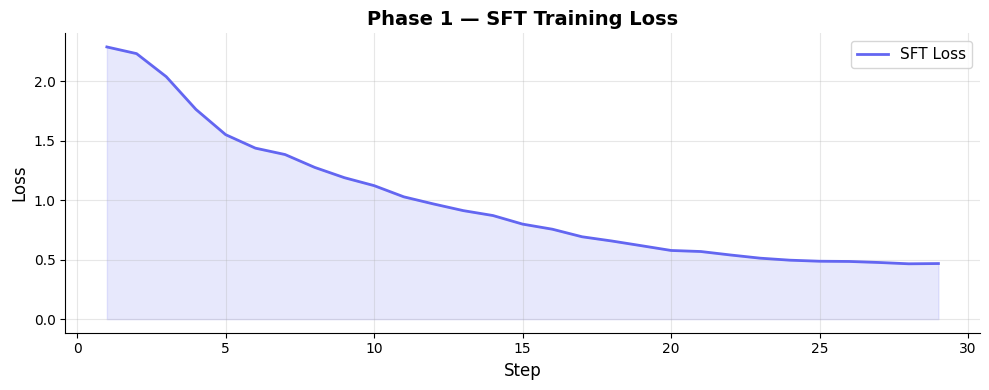

SFT Loss: 2.2865 → 0.4668


In [63]:
# 📊 SFT Training Loss Curve
import matplotlib.pyplot as plt

sft_log = [x for x in sft_trainer.state.log_history if 'loss' in x]
sft_steps = [x['step'] for x in sft_log]
sft_losses = [x['loss'] for x in sft_log]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sft_steps, sft_losses, color='#6366f1', linewidth=2, label='SFT Loss')
ax.fill_between(sft_steps, sft_losses, alpha=0.15, color='#6366f1')
ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Phase 1 — SFT Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('sft_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'SFT Loss: {sft_losses[0]:.4f} → {sft_losses[-1]:.4f}')

In [64]:
sft_trainer.save_model(SFT_OUTPUT_DIR)
tokenizer.save_pretrained(SFT_OUTPUT_DIR)
print(f"✅ SFT model saved to {SFT_OUTPUT_DIR}/")

# Free memory
import torch, gc
del model, sft_trainer
gc.collect()
torch.cuda.empty_cache()

✅ SFT model saved to smart-emergency-sft/


---
# Phase 2 — GRPO with Unsloth

### Action Parsing

In [65]:
def parse_llm_action(text):
    """Extract action dict from LLM output."""
    m = re.search(r"```json\s*(.*?)```", text, re.DOTALL)
    if m:
        text = m.group(1)
    else:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if m:
            text = m.group(0)
    try:
        d = json.loads(text)
        # Validate required fields
        assert d.get("action_type") in ("dispatch", "duplicate", "hold")
        assert 1 <= int(d.get("severity_pred", 0)) <= 5
        return d
    except Exception:
        return None


def fallback_action(obs_text):
    free = parse_free_vehicles(obs_text)
    vtype = heuristic_vehicle_type(obs_text)
    vid = pick_free(free, vtype)
    if vid:
        return {"action_type": "dispatch", "severity_pred": heuristic_severity(obs_text),
                "is_duplicate": False, "vehicle_type": vtype, "vehicle_id": vid}
    busy_vid = pick_busy(parse_all_vehicles(obs_text), vtype)
    return {"action_type": "hold" if busy_vid else "dispatch",
            "severity_pred": heuristic_severity(obs_text), "is_duplicate": False,
            "vehicle_type": vtype, "vehicle_id": busy_vid or f"{vtype}_0"}

### GRPO Setup — Seed-based Environment Reward

Root cause of reward=0: the old `rollout_func` + `reward_fns` architecture
was broken because GRPOTrainer generates its own completions and passes only
dataset kwargs to reward_fns — the pre-computed rewards from `rollout_func`
never reached the reward functions.

Fix: store (seed, task_id, obs_text) in the dataset so the reward function
can reset the env to the exact same starting state and step it once with the
model's actual completion to get a real environment reward.

In [66]:
# Fix peft/transformers version mismatch — stub the missing class
import transformers.integrations.tensor_parallel as _tp
if not hasattr(_tp, 'EmbeddingParallel'):
    _tp.EmbeddingParallel = _tp.ColwiseParallel
    print("⚠️ Patched missing EmbeddingParallel")

In [67]:
from unsloth import FastLanguageModel, PatchFastRL
from trl import GRPOConfig, GRPOTrainer

# Patch TRL for Unsloth compatibility
PatchFastRL("GRPO", FastLanguageModel)

# Load WITHOUT fast_inference to avoid vLLM version conflicts
grpo_model, grpo_tokenizer = FastLanguageModel.from_pretrained(
    model_name=SFT_OUTPUT_DIR,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)

grpo_model = FastLanguageModel.get_peft_model(
    grpo_model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    use_gradient_checkpointing="unsloth",
)

Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.
==((====))==  Unsloth 2026.4.8: Fast Qwen3 patching. Transformers: 4.57.6. vLLM: 0.19.1.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat

Unsloth: Already have LoRA adapters! We shall skip this step.


In [68]:
def make_user_prompt(obs_text):
    return f"You are the dispatcher. Read the situation and respond with a single JSON action.\n\n{obs_text}\n\nRespond ONLY with a JSON object."


def action_dict_to_obj(d):
    """Convert a plain dict action to SmartEmergencyAction."""
    from smart_emergency import RerouteAction
    reroute = None
    rd = d.get("reroute")
    if rd and isinstance(rd, dict) and rd.get("vehicle_to_reroute") and rd.get("from_event_id"):
        reroute = RerouteAction(
            vehicle_to_reroute=rd["vehicle_to_reroute"],
            from_event_id=rd["from_event_id"],
            replacement_vehicle_id=rd.get("replacement_vehicle_id"),
        )
    return SmartEmergencyAction(
        action_type=d.get("action_type", "dispatch"),
        severity_pred=int(d.get("severity_pred", 1)),
        is_duplicate=bool(d.get("is_duplicate", False)),
        duplicate_of_event_id=d.get("duplicate_of_event_id"),
        vehicle_type=d.get("vehicle_type"),
        vehicle_id=d.get("vehicle_id"),
        reroute=reroute,
    )

In [69]:
# Pre-generate the GRPO dataset: each example stores the seed + task_id so
# the reward function can reproduce the exact same env state deterministically.
print("🗺️  Pre-generating GRPO episode starting states …")
_grpo_rows = []
for _i in range(500):
    _task_id = (_i % 3) + 1
    _seed = _i * 17 + _task_id          # deterministic, spread across seeds
    _result = env.reset(task_id=_task_id, seed=_seed)
    _obs_text = _result.observation.prompt
    # Build the full chat prompt the model will see
    _messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": make_user_prompt(_obs_text)},
    ]
    _prompt_text = grpo_tokenizer.apply_chat_template(
        _messages, add_generation_prompt=True, tokenize=False, enable_thinking=False,
    )
    _grpo_rows.append({
        "prompt": _prompt_text,
        "seed": _seed,
        "task_id": _task_id,
    })
    if (_i + 1) % 100 == 0:
        print(f"  {_i+1}/500 episodes sampled")

from datasets import Dataset
grpo_dataset = Dataset.from_list(_grpo_rows)
print(f"✅ GRPO dataset ready: {len(grpo_dataset)} examples")

🗺️  Pre-generating GRPO episode starting states …
  100/500 episodes sampled
  200/500 episodes sampled
  300/500 episodes sampled
  400/500 episodes sampled
  500/500 episodes sampled
✅ GRPO dataset ready: 500 examples


In [70]:
# ---------------------------------------------------------------------------
# Single reward function — receives the model's completion + dataset kwargs.
#
# IMPORTANT: TRL's GRPOTrainer repeats completions num_generations times but
# does NOT replicate the extra dataset columns (seed, task_id) — they keep
# one entry per original example.  We read them from **kwargs and expand them
# manually so every completion gets the right env starting state.
# ---------------------------------------------------------------------------
def env_reward_fn(prompts, completions, **kwargs):
    """
    Real environment reward for each completion.

    seed + task_id are stored per-example in the dataset. TRL passes them
    as lists with len == batch_size (not num_generations * batch_size), so
    we tile them to match len(completions).
    """
    n = len(completions)
    raw_seeds    = kwargs.get("seed",    [18]) 
    raw_task_ids = kwargs.get("task_id", [1])

    # Convert tensors → Python ints if needed
    raw_seeds    = [int(s) for s in raw_seeds]
    raw_task_ids = [int(t) for t in raw_task_ids]

    # Tile to cover all num_generations completions
    seeds    = [raw_seeds[i    % len(raw_seeds)]    for i in range(n)]
    task_ids = [raw_task_ids[i % len(raw_task_ids)] for i in range(n)]

    rewards = []
    for completion, s, tid in zip(completions, seeds, task_ids):
        # ── 1. Reproduce the exact starting observation ──────────────────
        try:
            step_result = env.reset(task_id=tid, seed=s)
        except Exception as e:
            rewards.append(-1.0)
            continue

        # ── 2. Parse the model's completion ─────────────────────────────
        action_d = parse_llm_action(completion)
        format_ok = action_d is not None
        if action_d is None:
            rewards.append(-2.0)          # heavy penalty for bad JSON
            continue

        # ── 3. Step the env with this action ────────────────────────────
        try:
            action = action_dict_to_obj(action_d)
            step_result = env.step(action)
            bd = step_result.observation.reward_breakdown
            env_total = bd.get("total", 0.0)
        except Exception:
            env_total = -1.0

        # ── 4. Combine env reward + format bonus ─────────────────────────
        reward = env_total + 0.5          # +0.5 for valid JSON
        rewards.append(float(reward))

    return rewards

### GRPO Config & Trainer

In [71]:
grpo_config = GRPOConfig(
    num_train_epochs=1,
    learning_rate=5e-6,
    gradient_accumulation_steps=16,
    per_device_train_batch_size=1,
    warmup_steps=10,
    num_generations=4,
    max_completion_length=256,          # JSON action is ~60-70 tokens
    max_prompt_length=MAX_SEQ_LENGTH,
    temperature=1.0,                    # higher temp → more diversity → reward_std stays up
    # No use_vllm — uses HF generate to avoid vLLM version conflicts
    output_dir=GRPO_OUTPUT_DIR,
    logging_steps=1,
    save_steps=10,
    push_to_hub=True,
)

### Train GRPO

In [43]:
grpo_trainer = GRPOTrainer(
    model=grpo_model,
    processing_class=grpo_tokenizer,
    reward_funcs=[env_reward_fn],    # single fn that talks to the env
    train_dataset=grpo_dataset,
    args=grpo_config,
    # No rollout_func — GRPOTrainer generates completions via vLLM;
    # env_reward_fn evaluates them by replaying the env from the stored seed.
)

import torch
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name} | {round(gpu.total_memory/1024**3, 1)} GB")
print(f"Reserved: {round(torch.cuda.max_memory_reserved()/1024**3, 2)} GB")

GPU: NVIDIA A100-SXM4-80GB | 79.3 GB
Reserved: 10.11 GB


In [44]:
print("🏋️ Starting GRPO training …")
stats = grpo_trainer.train()
print("✅ GRPO complete")

🏋️ Starting GRPO training …


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 17,432,576 of 1,738,007,552 (1.00% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / env_reward_fn / mean,rewards / env_reward_fn / std
1,0.000600,2.053958,1.076256,51.125000,47.000000,53.000000,0.000000,51.125000,47.000000,53.000000,0.602560,2.053958,1.889708
2,0.000400,1.833333,1.205186,50.750000,47.000000,53.000000,0.000000,50.750000,47.000000,53.000000,0.418165,1.833333,1.902789
3,0.000500,1.893333,0.751256,51.125000,47.000000,53.000000,0.000000,51.125000,47.000000,53.000000,0.520460,1.893333,2.138244
4,0.000500,2.374583,0.179746,51.125000,47.000000,53.000000,0.000000,51.125000,47.000000,53.000000,0.497821,2.374583,2.077671
5,0.000500,1.695417,0.979820,50.375000,47.000000,53.000000,0.000000,50.375000,47.000000,53.000000,0.549491,1.695417,1.967849
6,0.000400,1.249792,0.961102,51.500000,47.000000,53.000000,0.000000,51.500000,47.000000,53.000000,0.448835,1.249792,1.513091
7,0.000400,2.114583,0.161303,52.625000,47.000000,53.000000,0.000000,52.625000,47.000000,53.000000,0.408024,2.114583,1.789679
8,0.000200,3.138333,0.050000,53.000000,53.000000,53.000000,0.000000,53.000000,53.000000,53.000000,0.228626,3.138333,1.456546
9,0.000300,2.258958,0.186485,52.625000,47.000000,53.000000,0.000000,52.625000,47.000000,53.000000,0.343496,2.258958,1.763103
10,0.000200,3.920000,0.528171,53.000000,53.000000,53.000000,0.000000,53.000000,53.000000,53.000000,0.241777,3.920000,0.856861


KeyboardInterrupt: 

In [ ]:
# 📊 GRPO Training Curves — Reward & Loss
import matplotlib.pyplot as plt

grpo_log = [x for x in grpo_trainer.state.log_history if 'reward' in x]
g_steps   = [x['step'] for x in grpo_log]
g_rewards = [x['reward'] for x in grpo_log]
g_losses  = [x.get('loss', 0) for x in grpo_log]
g_kl      = [x.get('kl', 0) for x in grpo_log]
g_rstd    = [x.get('reward_std', 0) for x in grpo_log]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Reward
ax = axes[0, 0]
ax.plot(g_steps, g_rewards, color='#10b981', linewidth=2, label='Reward')
ax.fill_between(g_steps, g_rewards, alpha=0.15, color='#10b981')
ax.set_title('Reward ↑', fontsize=13, fontweight='bold')
ax.set_ylabel('Reward')
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Loss
ax = axes[0, 1]
ax.plot(g_steps, g_losses, color='#ef4444', linewidth=2, label='Loss')
ax.fill_between(g_steps, g_losses, alpha=0.15, color='#ef4444')
ax.set_title('Policy Loss', fontsize=13, fontweight='bold')
ax.set_ylabel('Loss')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# KL Divergence
ax = axes[1, 0]
ax.plot(g_steps, g_kl, color='#f59e0b', linewidth=2, label='KL Divergence')
ax.fill_between(g_steps, g_kl, alpha=0.15, color='#f59e0b')
ax.set_title('KL Divergence', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('KL')
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Reward Std
ax = axes[1, 1]
ax.plot(g_steps, g_rstd, color='#8b5cf6', linewidth=2, label='Reward Std')
ax.fill_between(g_steps, g_rstd, alpha=0.15, color='#8b5cf6')
ax.set_title('Reward Std (diversity)', fontsize=13, fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Std')
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Phase 2 — GRPO Training Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grpo_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Reward: {g_rewards[0]:.2f} → {g_rewards[-1]:.2f}  |  KL: {g_kl[0]:.4f} → {g_kl[-1]:.4f}')

In [ ]:
peak = round(torch.cuda.max_memory_reserved() / 1024**3, 2)
print(f"Peak memory: {peak} GB | Time: {round(stats.metrics['train_runtime']/60, 1)} min")

grpo_trainer.save_model(GRPO_OUTPUT_DIR)
grpo_trainer.push_to_hub()
print(f"✅ Model saved & pushed to Hub")

---
# Phase 3 — Inference & Evaluation

In [ ]:
from unsloth import FastLanguageModel as FLM

inf_model, inf_tokenizer = FLM.from_pretrained(
    model_name=GRPO_OUTPUT_DIR, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True,
)
FLM.for_inference(inf_model)

def run_episode(env, model, tokenizer, task_id=1):
    result = env.reset(task_id=task_id)
    total_reward = 0.0

    for step in range(20):
        if result.done:
            break
        obs_text = result.observation.prompt
        try:
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": make_user_prompt(obs_text)},
            ]
            prompt_text = tokenizer.apply_chat_template(
                messages, add_generation_prompt=True, tokenize=False, enable_thinking=False,
            )
            inputs = tokenizer([prompt_text], return_tensors="pt").to(model.device)
            gen = model.generate(**inputs, max_new_tokens=256, temperature=0.1)
            output = tokenizer.decode(gen[0][len(inputs.input_ids[0]):], skip_special_tokens=True)

            action_d = parse_llm_action(output) or fallback_action(obs_text)
            tag = "✅" if parse_llm_action(output) else "⚠️"
            print(f"  Step {step}: {tag} {action_d.get('action_type')} sev={action_d.get('severity_pred')}")
        except Exception as e:
            print(f"  Step {step}: ❌ {e}")
            action_d = fallback_action(obs_text)

        action = action_dict_to_obj(action_d)
        result = env.step(action)
        total_reward += result.observation.reward_breakdown.get("total", 0.0)

    print(f"\n  Done — reward: {total_reward:.2f} over {step+1} steps")
    return total_reward

In [ ]:
for _tid, _name in [(1, "Easy"), (2, "Medium"), (3, "Hard")]:
    print(f"\n{'='*50}")
    print(f"Evaluation — Task {_tid} ({_name})")
    print(f"{'='*50}")
    run_episode(env, inf_model, inf_tokenizer, task_id=_tid)

env.close()